# Флэшмоб в ленте: оценка эффекта

## Краткий вывод

Учебный проект по теме **«Прогнозирование метрик» курса «Симулятор аналитика» Karpov.Courses**. По агрегированным событиям ленты оцениваем эффект флэшмоба 10–16 июля 2026 года с помощью CausalImpact.

Основной результат: во время мероприятия выросли просмотры, CTR и число уникальных просматриваемых постов; убедительного роста DAU и числа новых постов нет. После 16 июля устойчивый дополнительный эффект визуально не сохраняется.

> Датасет учебный: это обезличенная дневная витрина из `simulator_20260720.feed_actions`, а не данные реального работодателя.

## Контекст и методика

- **Бизнес-вопрос:** изменил ли флэшмоб пользовательскую активность?
- **Пре-период:** 30 мая — 9 июля 2026 года.
- **Пост-период:** 10–16 июля 2026 года.
- **Метод:** байесовская структурная модель временного ряда через `tfcausalimpact`.
- **Ограничение:** контрольного ряда нет, поэтому это квазиэкспериментальная, а не равная A/B-тесту оценка причинного эффекта.

In [1]:
import os
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
from causalimpact import CausalImpact

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PRE_PERIOD = ["2026-05-30", "2026-07-09"]
POST_PERIOD = ["2026-07-10", "2026-07-16"]

cwd = Path.cwd()
candidates = [
    cwd / "data" / "flashmob_daily_metrics.csv",
    cwd.parent / "data" / "flashmob_daily_metrics.csv",
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Не найден data/flashmob_daily_metrics.csv")

## Данные

Одна строка — один полный календарный день. `DAU` — уникальные пользователи с событием в ленте; `CTR = likes / views`. Неполный день 1 августа исключён.

In [2]:
metrics = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date")

expected_dates = pd.date_range(metrics.index.min(), metrics.index.max(), freq="D")
checks = pd.Series({
    "строк": len(metrics),
    "дубликатов дат": int(metrics.index.duplicated().sum()),
    "пропущенных дней": len(expected_dates.difference(metrics.index)),
    "пропусков": int(metrics.isna().sum().sum()),
    "максимальная ошибка CTR": float(
        (metrics["ctr"] - metrics["likes"] / metrics["views"]).abs().max()
    ),
})

assert checks["дубликатов дат"] == 0
assert checks["пропущенных дней"] == 0
assert checks["пропусков"] == 0
assert checks["максимальная ошибка CTR"] < 1e-8
display(checks.to_frame("значение"))
display(metrics.head())

,значение
строк,63.000
дубликатов дат,0.000
пропущенных дней,0.000
пропусков,0.000
максимальная ошибка CTR,0.000


,dau,likes,views,ctr,unique_viewed_posts,new_posts
date,,,,,,
2026-05-30,878,1560,7603,0.205,89,89
2026-05-31,2238,12816,62770,0.204,178,97
2026-06-01,3105,20958,105526,0.199,191,61
2026-06-02,3721,23800,118996,0.200,211,87
2026-06-03,4617,34504,174454,0.198,214,70


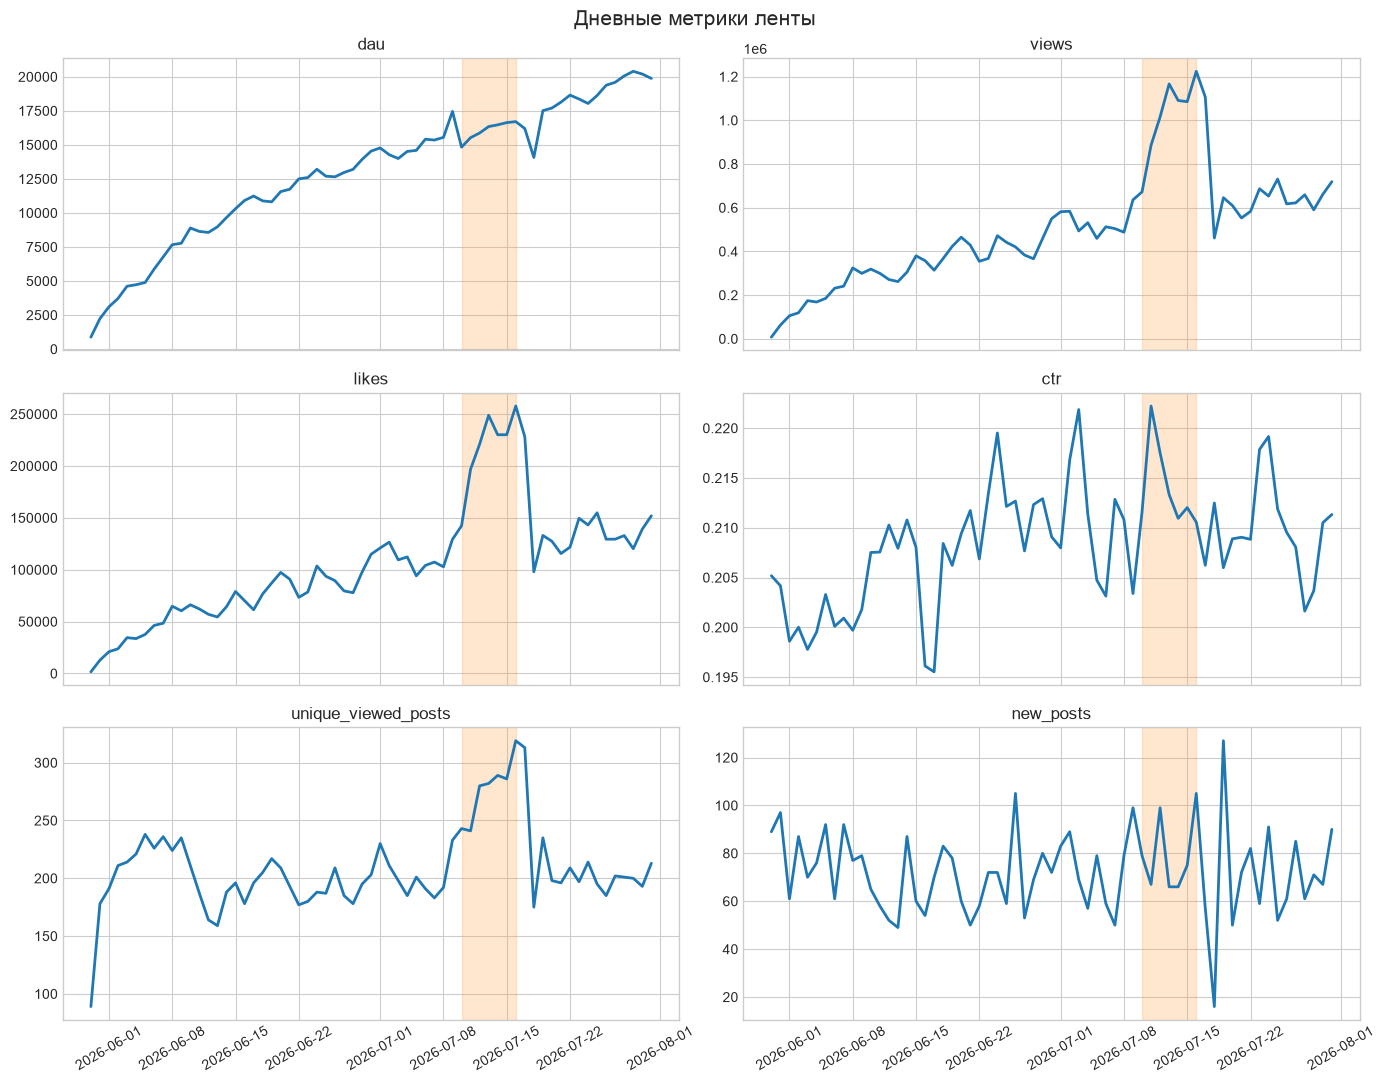

In [3]:
plot_cols = ["dau", "views", "likes", "ctr", "unique_viewed_posts", "new_posts"]
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)

for ax, col in zip(axes.flat, plot_cols):
    ax.plot(metrics.index, metrics[col], linewidth=2)
    ax.axvspan(pd.Timestamp(POST_PERIOD[0]), pd.Timestamp(POST_PERIOD[1]),
               color="#ff9f43", alpha=0.25, label="флэшмоб")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Дневные метрики ленты", fontsize=15)
fig.tight_layout()
plt.show()

## Результаты

Модель строит контрфактический прогноз для 10–16 июля. Эффект — разница между фактом и прогнозом без флэшмоба. Если 95%-й интервал включает ноль, изменение не считаем статистически убедительным.

In [4]:
def fit_impact(metric):
    impact = CausalImpact(metrics[[metric]], PRE_PERIOD, POST_PERIOD)
    row = impact.summary_data["average"]
    lower = float(row["abs_effect_lower"])
    upper = float(row["abs_effect_upper"])
    significant = not (lower <= 0 <= upper)
    direction = "рост" if float(row["abs_effect"]) > 0 else "снижение"
    return impact, {
        "metric": metric,
        "actual": float(row["actual"]),
        "predicted": float(row["predicted"]),
        "effect": float(row["abs_effect"]),
        "ci_lower": lower,
        "ci_upper": upper,
        "result": direction if significant else "нет убедительного изменения",
    }

model_metrics = ["dau", "ctr", "views", "new_posts", "unique_viewed_posts"]
impacts, rows = {}, []
for metric in model_metrics:
    impacts[metric], result = fit_impact(metric)
    rows.append(result)

results = pd.DataFrame(rows).set_index("metric")
results

Instructions for updating:
Please use `StructuralTimeSeries.joint_distribution(observed_time_series).log_prob`


Instructions for updating:
`Predictive distributions returned by`tfp.sts.one_step_predictive` will soon compute per-timestep probabilities (treating timesteps as part of the batch shape) instead of a single probability for an entire series (the current approach, in which timesteps are treated as event shape). Please update your code to pass `timesteps_are_event_shape=False` (this will soon be the default) and to explicitly sum over the per-timestep log probabilities if this is required.


,actual,predicted,effect,ci_lower,ci_upper,result
metric,,,,,,
dau,"16,052.714","15,201.381",851.333,"-1,299.736","3,014.380",нет убедительного изменения
ctr,0.214,0.207,0.007,0.002,0.011,рост
views,"1,019,947.312","363,324.938","656,622.375","563,490.447","750,298.544",рост
new_posts,79.571,72.027,7.545,-1.936,17.207,нет убедительного изменения
unique_viewed_posts,277.143,197.347,79.796,61.704,96.352,рост


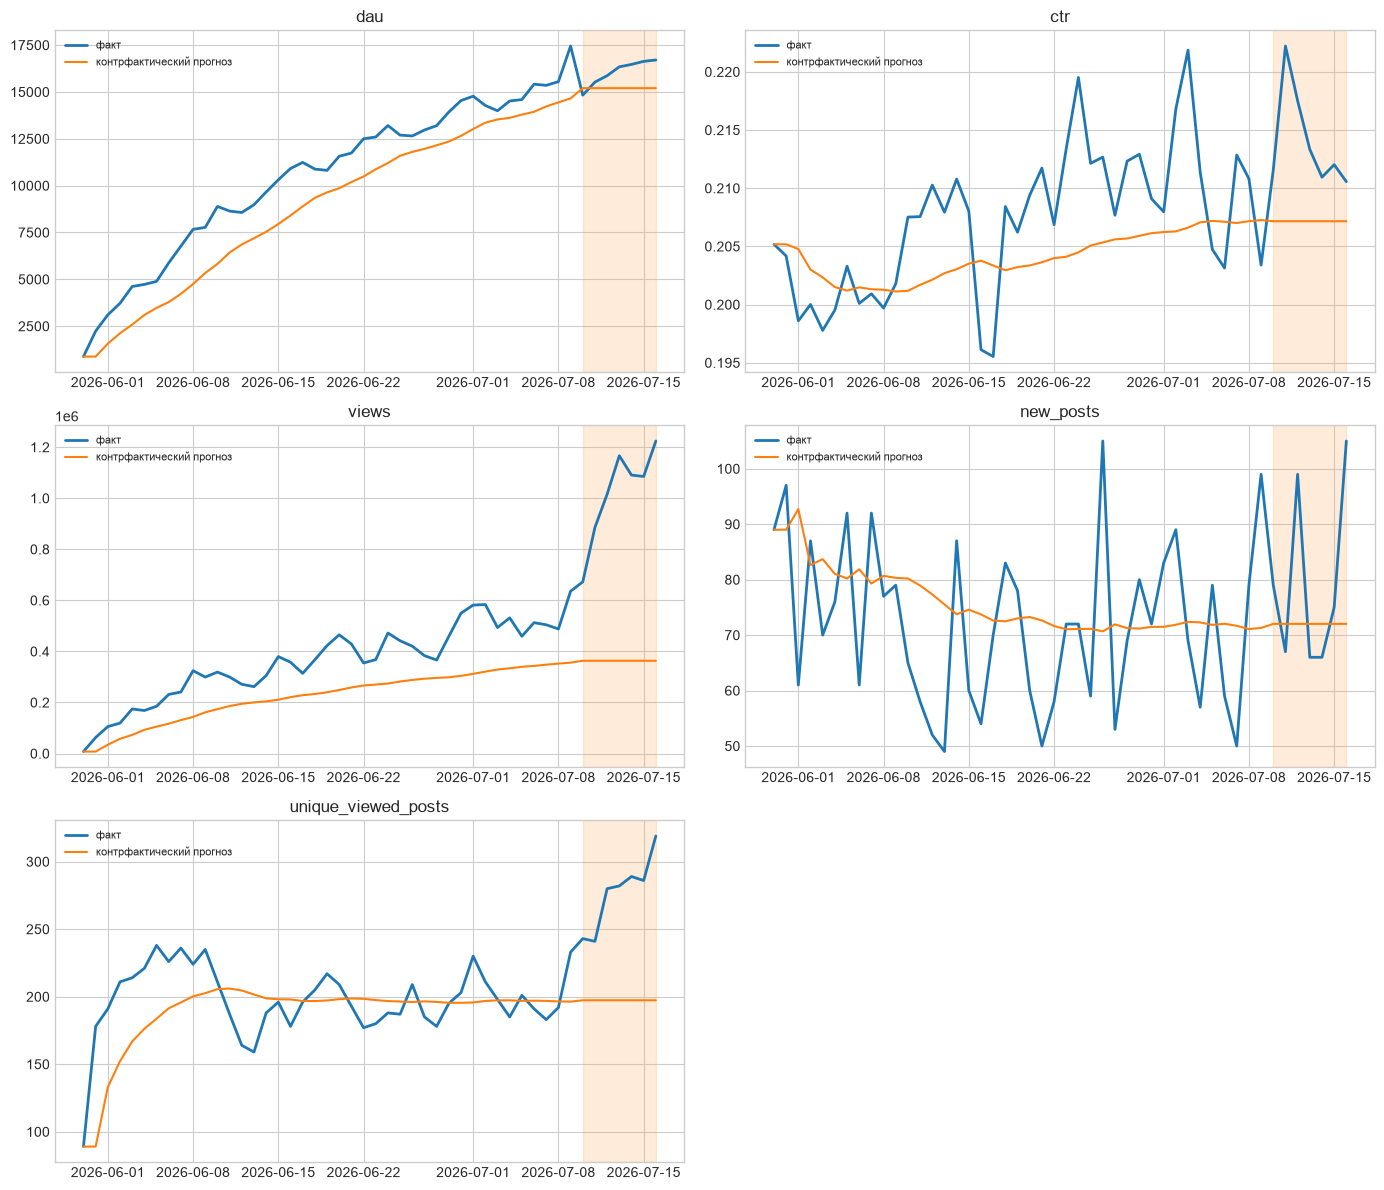

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, metric in zip(axes.flat, model_metrics):
    inf = impacts[metric].inferences
    ax.plot(inf.index, metrics.loc[inf.index, metric], label="факт", linewidth=2)
    ax.plot(inf.index, inf["complete_preds_means"], label="контрфактический прогноз", linewidth=1.5)
    ax.axvspan(pd.Timestamp(POST_PERIOD[0]), pd.Timestamp(POST_PERIOD[1]),
               color="#ff9f43", alpha=0.2)
    ax.set_title(metric)
    ax.legend(fontsize=8)

axes.flat[-1].axis("off")
fig.tight_layout()
plt.show()

##### Итоговые выводыовые выводыовые выводыовые выводы

1. Флэшмоб усилил потребление контента: наиболее заметны просмотры и число уникальных просматриваемых постов.
2. CTR вырос, то есть глубина взаимодействия улучшилась не только за счёт большего числа показов.
3. Для DAU и новых постов уверенного эффекта нет: мероприятие сильнее повлияло на уже активную аудиторию.
4. После мероприятия метрики возвращаются к прежней траектории; устойчивого долгосрочного эффекта не видно.
5. Результаты зависят от допущения, что одновременно не было других крупных изменений продукта или маркетинга.